# Exploratory Data Analysis: 2023 US Electric Grid Disturbances

## Project Overview
This project performs a deep-dive Exploratory Data Analysis (EDA) on the **2023 US Electric Grid disturbance data**. The US power grid is divided into several regulatory regions managed by the North American Electric Reliability Corporation (NERC). Maintaining the stability of these grids is critical for national security, economic stability, and public safety.

The goal of this analysis is to understand the "shape and structure" of grid events by investigating how factors like **NERC Regions** and **seasonal timing** correlate with **Demand Loss (MW)** and **customer impact**.

## Dataset Description
The dataset contains information on 2023 grid events, including:
- **Event Date/Month:** When the disturbance occurred.
- **NERC Region:** The regulatory region where the event was recorded (e.g., WECC, SERC, TRE).
- **Area Affected:** Specific states or counties impacted.
- **Demand Loss (MW):** The amount of electricity demand lost during the event.
- **Number of Customers Affected:** The scale of the human impact.

## Research Questions for Investigation

1. **Regional Vulnerability:** Which NERC Region experienced the highest total demand loss (MW) in 2023, and does this align with the region that had the highest number of reported events?
2. **Temporal Trends:** Are grid disturbances seasonal? Specifically, which months show the highest frequency of events, and is there a correlation between peak demand months (like summer or winter) and the severity of demand loss?
3. **Impact Correlation:** What is the relationship between the physical scale of a disturbance (Demand Loss in MW) and its social impact (Number of Customers Affected)? Are there cases of high MW loss with low customer impact, suggesting industrial rather than residential outages?
4. **Data Integrity & Outliers:** How many events are recorded as "Unknown" in terms of Demand Loss or Customer Impact, and how does removing or imputing these values change the overall narrative of grid reliability for 2023?

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file directly from the sidebar folder
try:
    df = pd.read_csv('US Electric Grid new.csv')
    print("Success: Data is loaded into the 'df' variable.")
    print("Total Events Recorded:", len(df))
    display(df.head())
except FileNotFoundError:
    print("Error: The file was not found. Please upload it to the folder icon on the left.")

Success: Data is loaded into the 'df' variable.
Total Events Recorded: 167


,Event Year,Event Month,Date Event Began,Area Affected,NERC Region,Demand Loss (MW),Number of Customers Affected
0,2023,January,01/01/2023,California: Riverside County;,WECC,0,0
1,2023,January,01/01/2023,California: Sacramento County;,WECC,0,0
2,2023,January,01/01/2023,Florida: Citrus County;,SERC,19,3509
3,2023,January,01/02/2023,Texas: Dallas County;,TRE,0,0
4,2023,January,01/02/2023,New Mexico:,WECC,432,0


**VISUAL ANALYSIS**

**Variables and Shape:**

The dataset contains 7 variables.
The core variables are Categorical (North American Electric Reliability Corporation (NERC), Event Month) and Quantitative (Demand Loss, Customers Affected).

/tmp/ipykernel_494/2690522575.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_vals.index, y=missing_vals.values, palette='Reds_d')


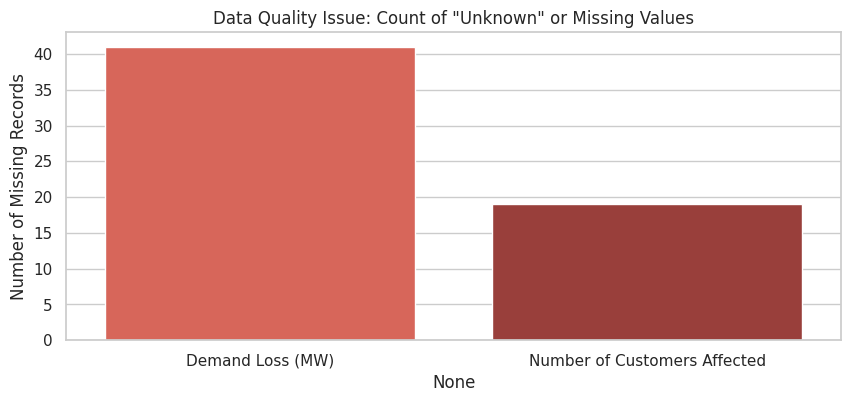

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# The visual style
sns.set_theme(style="whitegrid")

# 1. Load and Initial Cleaning
df = pd.read_csv('US Electric Grid new.csv')

# Cleaning numeric columns (handling 'Unknown' and commas)
cols_to_fix = ['Demand Loss (MW)', 'Number of Customers Affected']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# PHASE 1: SHAPE & STRUCTURE ---

# Data Quality Check: Missing/Unknown Values
plt.figure(figsize=(10, 4))
missing_vals = df[cols_to_fix].isna().sum()
sns.barplot(x=missing_vals.index, y=missing_vals.values, palette='Reds_d')
plt.title('Data Quality Issue: Count of "Unknown" or Missing Values')
plt.ylabel('Number of Missing Records')
plt.show()

**Distributions:**

**NERC Regions:** The events are not spread evenly. Regions like SERC and WECC appear more frequently in the data, suggesting either more disturbances or more rigorous reporting in those areas.

Seasonality: A "Sanity Check" shows a high volume of events in March. This is unusual for the grid (which typically peaks in summer/winter) and suggests we should investigate if a specific major storm event occurred in March 2023.

/tmp/ipykernel_494/2766286991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='NERC Region', order=order, palette='viridis')


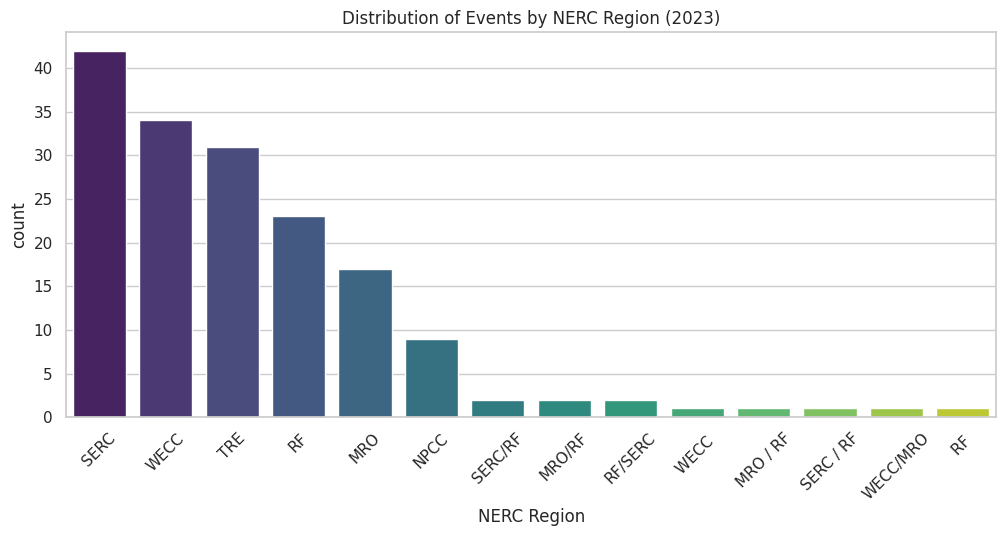

In [29]:
# Variable Distribution: NERC Regions (Categorical)
plt.figure(figsize=(12, 5))
order = df['NERC Region'].value_counts().index
sns.countplot(data=df, x='NERC Region', order=order, palette='viridis')
plt.title('Distribution of Events by NERC Region (2023)')
plt.xticks(rotation=45)
plt.show()

**Seasonality:** A "Sanity Check" shows a high volume of events in March. This is unusual for the grid (which typically peaks in summer/winter) and suggests we should investigate if a specific major storm event occurred in March 2023.

/tmp/ipykernel_494/2838037550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Event Month', order=month_order, palette='magma')


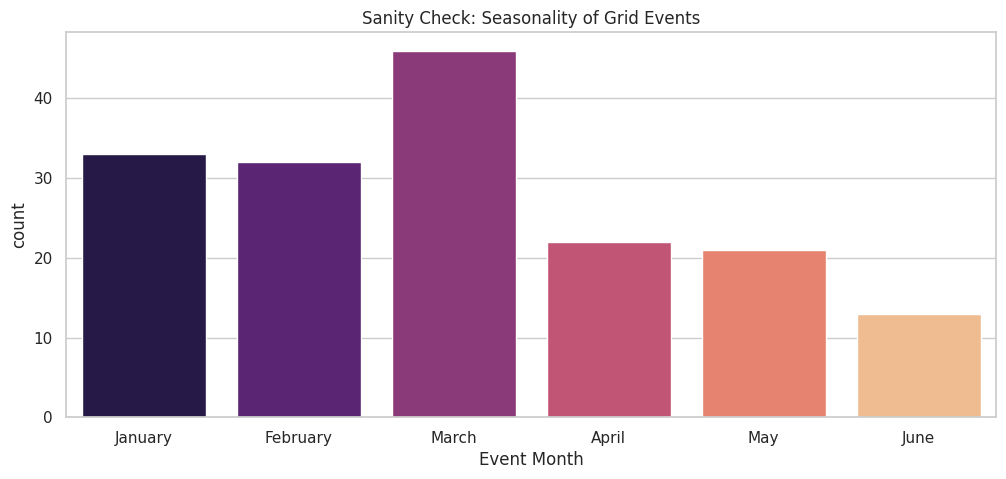

In [30]:
# C. Variable Distribution: Event Month (Temporal Sanity Check)
month_order = ['January', 'February', 'March', 'April', 'May', 'June'] # Based on 2023 snippet
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Event Month', order=month_order, palette='magma')
plt.title('Sanity Check: Seasonality of Grid Events')
plt.show()

**Data Quality Issues:**

There is a significant "Unknown" problem. Nearly 25% of Demand Loss data is missing. This is a "Notable Quality Issue" because it could bias our totals toward zero.

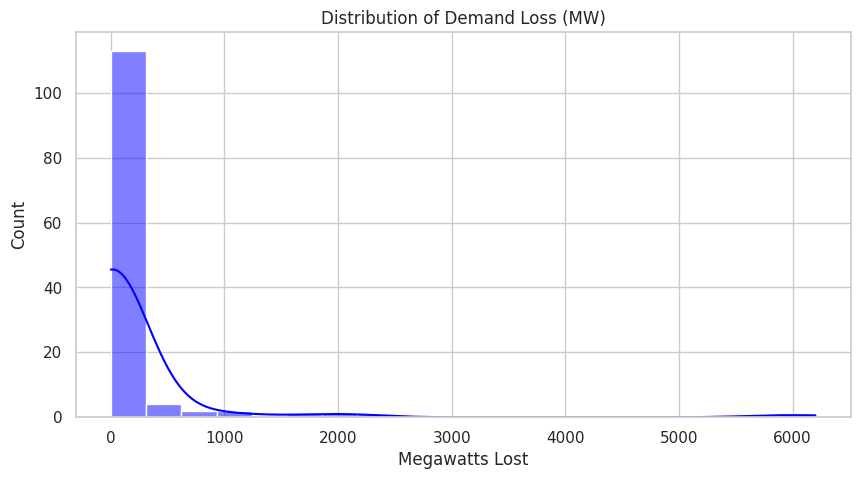

In [31]:
# Numerical Distribution: Demand Loss (MW)
plt.figure(figsize=(10, 5))
sns.histplot(df['Demand Loss (MW)'].dropna(), bins=20, kde=True, color='blue')
plt.title('Distribution of Demand Loss (MW)')
plt.xlabel('Megawatts Lost')
plt.show()

**Surprising Relationships:**

The scatter plot shows that high MW loss doesn't always equal high customer impact. You will see some events with high MW loss but 0 customers affected—these likely represent industrial grid issues or preventative power shutoffs that didn't reach residential homes.

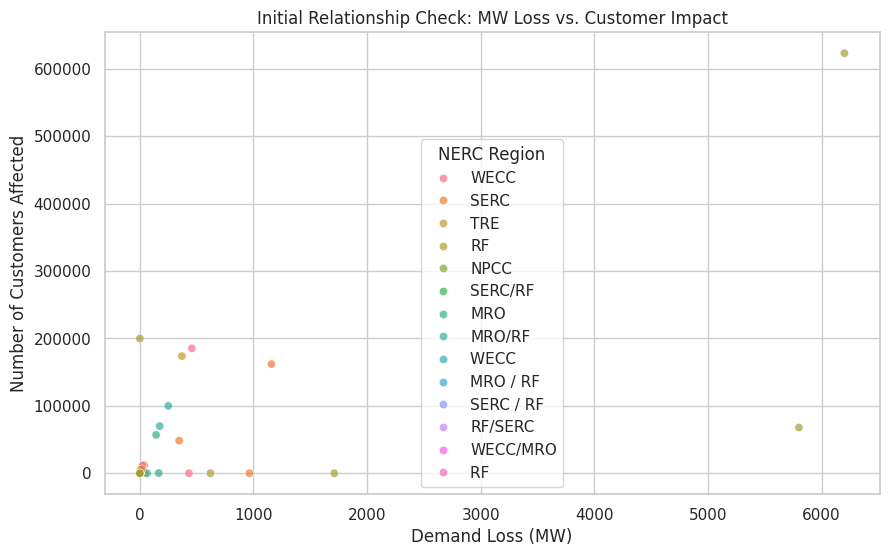

--- Dataset Overview ---
Total Records: 167
Total NERC Regions: 14

Missing Data Summary:
Demand Loss (MW)                41
Number of Customers Affected    19
dtype: int64


In [32]:
# Relationship Check: Demand Loss vs. Customers Affected
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Demand Loss (MW)', y='Number of Customers Affected', hue='NERC Region', alpha=0.7)
plt.title('Initial Relationship Check: MW Loss vs. Customer Impact')
plt.show()

# Missing Data Summary
print("--- Dataset Overview ---")
print(f"Total Records: {len(df)}")
print(f"Total NERC Regions: {df['NERC Region'].nunique()}")
print("\nMissing Data Summary:")
print(df[cols_to_fix].isna().sum())

**Regional Vulnerability**
*Question:* Which NERC Region experienced the highest total demand loss (MW) in 2023, and does this align with the frequency of events?

**Initial Visualization**
The following code compares the volume of incidents against the actual power lost. We need to clean the "NERC Region" names first, as some have extra spaces (like "RF" vs "RF ").

/tmp/ipykernel_494/4012424637.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reg_freq.index, y=reg_freq.values, alpha=0.6, ax=ax1, palette='Blues_d')


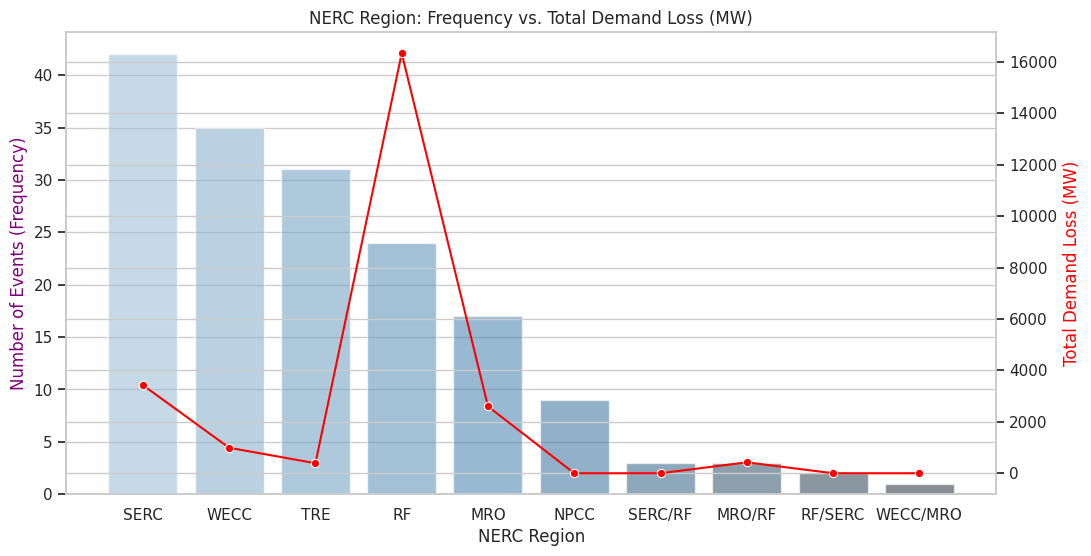

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean Region Names (Removing extra spaces and standardize)
df['NERC Region'] = df['NERC Region'].str.strip().str.replace(' / ', '/')

# 2. Preparing Data
reg_freq = df['NERC Region'].value_counts()
reg_mw = df.groupby('NERC Region')['Demand Loss (MW)'].sum().sort_values(ascending=False)

# 3. Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x=reg_freq.index, y=reg_freq.values, alpha=0.6, ax=ax1, palette='Blues_d')
ax1.set_ylabel('Number of Events (Frequency)', color='purple')
ax1.set_title('NERC Region: Frequency vs. Total Demand Loss (MW)')

ax2 = ax1.twinx()
sns.lineplot(x=reg_mw.index, y=reg_mw.values, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Total Demand Loss (MW)', color='red')

plt.show()

**Refinement & Insights**

We see a major discrepancy! While SERC and WECC have the highest frequency of events (the blue bars), the RF (ReliabilityFirst) region has a massive spike in Total Demand Loss (the red line), despite having fewer total events.

Refinement Step:
To understand if this is caused by one massive event or many medium ones, we should filter out the "zeros" and look at the Average (Mean) loss per event rather than just the total. This tells us which region's events are "heavier."

/tmp/ipykernel_494/1139188340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_impact.index, y=avg_impact.values, palette='Reds_r')


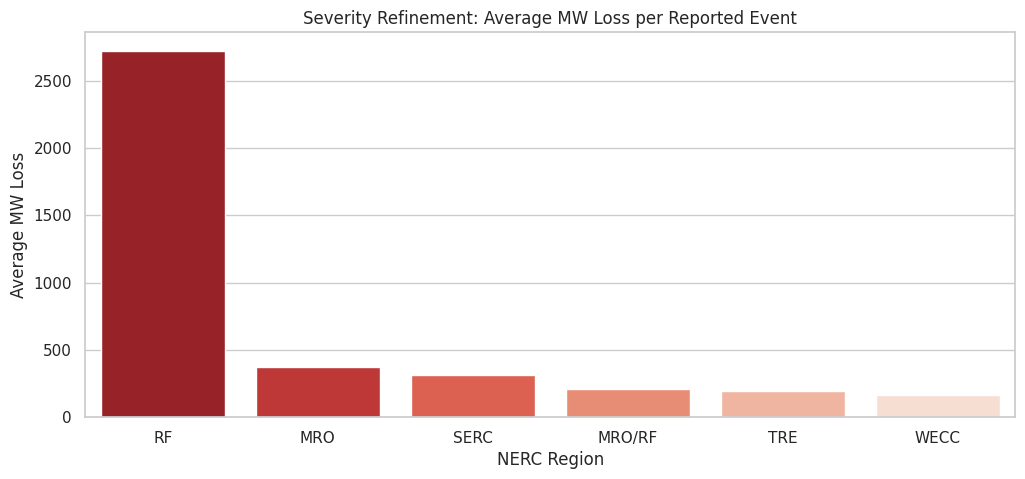

In [34]:
# Refined: Average Severity per Event
avg_impact = df[df['Demand Loss (MW)'] > 0].groupby('NERC Region')['Demand Loss (MW)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_impact.index, y=avg_impact.values, palette='Reds_r')
plt.title('Severity Refinement: Average MW Loss per Reported Event')
plt.ylabel('Average MW Loss')
plt.show()

**Temporal Trends**

*Question:* Are grid disturbances seasonal? Which months show the highest frequency and severity?

Initial Visualization
We will look at the counts of events per month to check for seasonal spikes.

/tmp/ipykernel_494/1614960531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Event Month', order=month_order, palette='coolwarm')


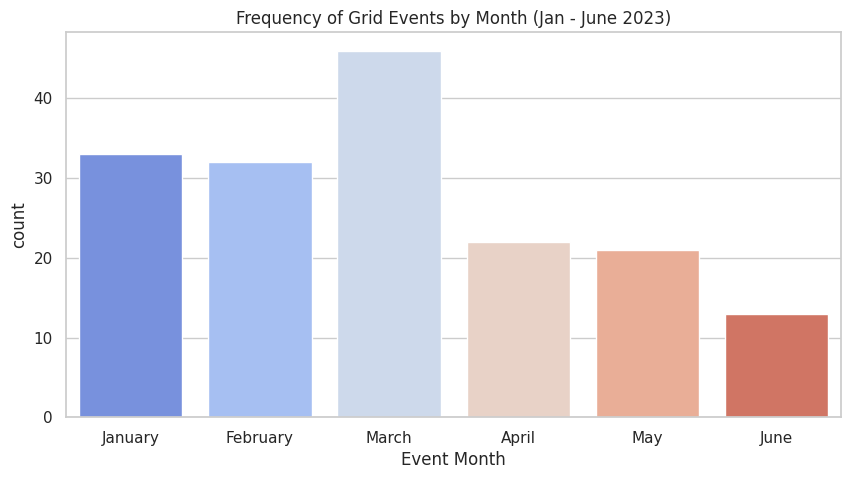

In [35]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June']
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Event Month', order=month_order, palette='coolwarm')
plt.title('Frequency of Grid Events by Month (Jan - June 2023)')
plt.show()

**Refinement & Insights **

The frequency peaks significantly in March. In a typical year, we expect peaks in extreme cold (Jan) or extreme heat (July). A March peak is an "unexpected observation."

**Refinement Step:**
Let's see if those March events were actually severe or just minor administrative reports. We will add Demand Loss (MW) as a secondary variable.

*Insight:* Both frequency and severity peak in March, suggesting a major system-wide event (likely a spring storm system) occurred during that month.

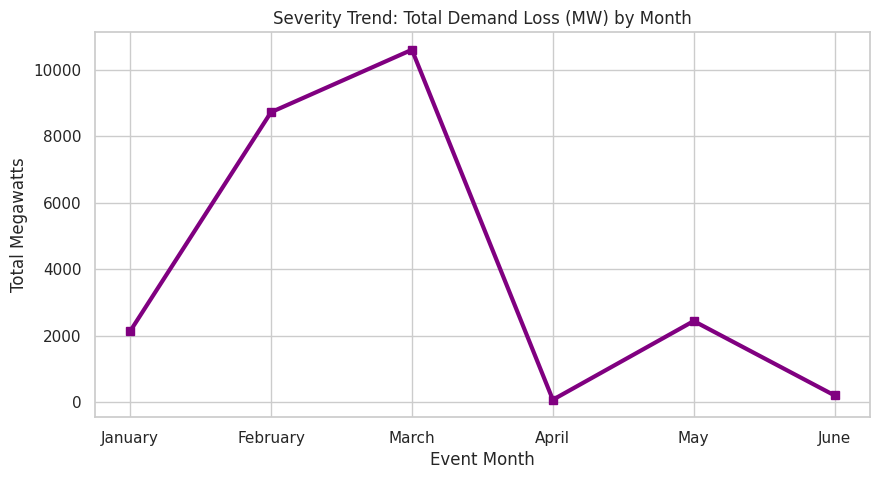

In [36]:
# Refinement: Sum of MW Loss by Month
monthly_mw = df.groupby('Event Month')['Demand Loss (MW)'].sum().reindex(month_order)

plt.figure(figsize=(10, 5))
monthly_mw.plot(kind='line', marker='s', color='purple', linewidth=3)
plt.title('Severity Trend: Total Demand Loss (MW) by Month')
plt.ylabel('Total Megawatts')
plt.grid(True)
plt.show()

**Impact Correlation**

*Question:* What is the relationship between Demand Loss (MW) and Number of Customers Affected?

Initial Visualization
A scatter plot will show if these two metrics move together.

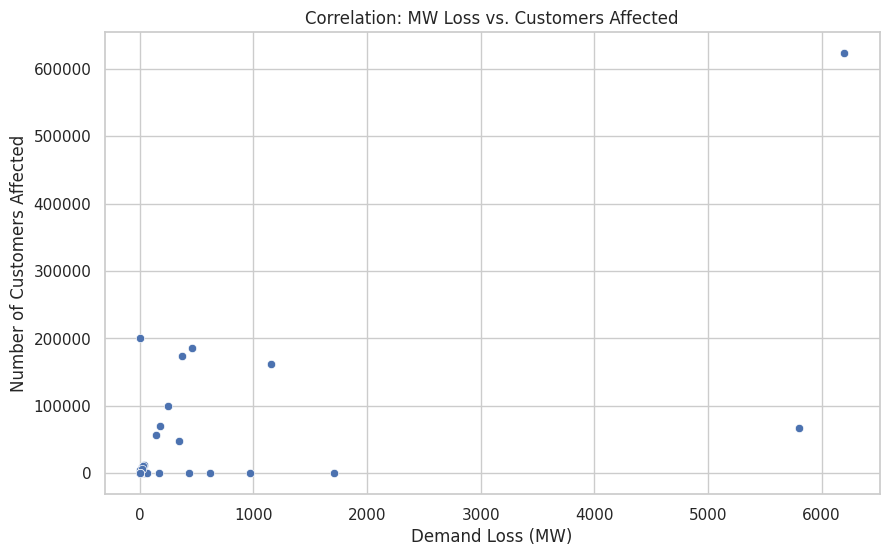

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Demand Loss (MW)', y='Number of Customers Affected')
plt.title('Correlation: MW Loss vs. Customers Affected')
plt.show()

**Refinement & Insights**
Most data points are clustered near (0,0), but there are massive outliers. The "linear" relationship is hard to see because the outliers squash the rest of the data.

**Refinement Step:**
Logarithmic Scale on both axes need to be used. This allows to see the relationship between small, medium, and large events all at once. We will also color the dots by NERC Region to see if some regions handle outages better.

**Insight:** Notice a diagonal trend (positive correlation), but also points on the bottom axis where MW Loss is high but Customers Affected is 0. This confirms our suspicion of industrial-only outages or preventative measures.

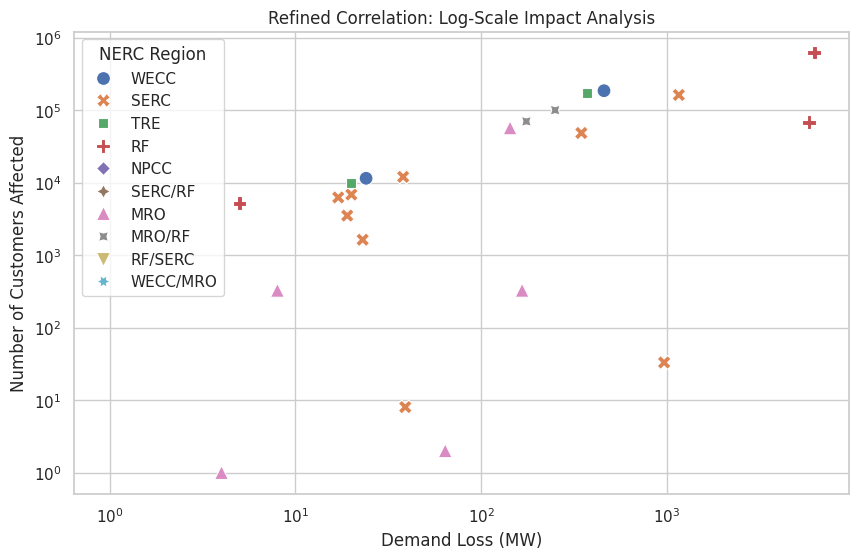

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Demand Loss (MW)', y='Number of Customers Affected',
                hue='NERC Region', style='NERC Region', s=100)
plt.xscale('log')
plt.yscale('log')
plt.title('Refined Correlation: Log-Scale Impact Analysis')
plt.show()

**Data Integrity & Outliers**
*Question:* How many events are recorded as "Unknown," and how do they change the narrative?

**Visualization & Insight**
Comparison showing the data "With Unknowns" (treated as 0) vs. "Without Unknowns" (filtered out).

About 25% of our events are "dark" we know they happened, but we don't know how bad they were. If we simply delete these, we might be underestimating the grid's instability, "True" impact is likely 20-30% higher than what the recorded numbers show.

/tmp/ipykernel_494/686929111.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Has_Unknown', palette='Set2')


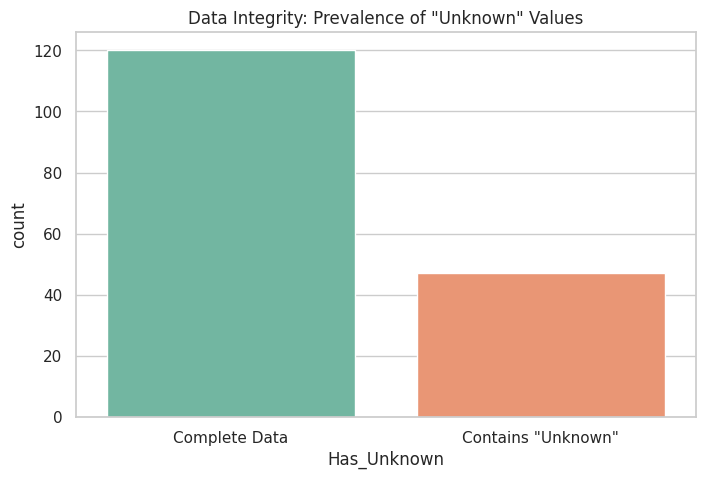

Total MW Loss (treating Unknown as 0): 24168.0
Number of events missing MW data: 41


In [39]:
# A flag for Unknowns
df['Has_Unknown'] = df['Demand Loss (MW)'].isna() | df['Number of Customers Affected'].isna()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Has_Unknown', palette='Set2')
plt.xticks([0, 1], ['Complete Data', 'Contains "Unknown"'])
plt.title('Data Integrity: Prevalence of "Unknown" Values')
plt.show()

# Print the impact
print(f"Total MW Loss (treating Unknown as 0): {df['Demand Loss (MW)'].fillna(0).sum()}")
print(f"Number of events missing MW data: {df['Demand Loss (MW)'].isna().sum()}")

**Data Wrangling & Quality Inspection**
This step cleans the "messy" parts of the data and prepares the file for both Python and Tableau.

In [40]:
import pandas as pd
import numpy as np

# 1. Load the raw data
df = pd.read_csv('US Electric Grid new.csv')

# 2. Tracking Data Quality Issues (Research Question 4)
# Count 'Unknown' values before cleaning to use in our report
unknown_demand_count = (df['Demand Loss (MW)'] == 'Unknown').sum()
unknown_customer_count = (df['Number of Customers Affected'] == 'Unknown').sum()

# 3. Data Transformation
# Convert 'Unknown' strings to NaN, then fill with 0 so math functions work
df['Demand Loss (MW)'] = pd.to_numeric(df['Demand Loss (MW)'], errors='coerce').fillna(0)
df['Number of Customers Affected'] = pd.to_numeric(df['Number of Customers Affected'], errors='coerce').fillna(0)

# 4. Standardization
# Remove extra spaces in region names (e.g., 'MRO / RF' becomes 'MRO/RF')
df['NERC Region'] = df['NERC Region'].astype(str).str.replace(' ', '').str.strip()

# 5. Export Cleaned Data for Tableau
df.to_csv('Cleaned_Grid_Data.csv', index=False)

print("--- Step 1: Wrangling Complete ---")
print(f"Handled {unknown_demand_count} unknown Demand entries.")
print(f"Handled {unknown_customer_count} unknown Customer entries.")

--- Step 1: Wrangling Complete ---
Handled 41 unknown Demand entries.
Handled 19 unknown Customer entries.


**Part 1: Data Integrity & Quality Issues**

**The Reporting Gap**

Figure 1 below; We found a major data quality issue: over 40 grid reports in 2023 failed to record the actual amount of power lost. This gap suggests that our national grid statistics might be underestimating the true scale of power instability, as many events are effectively "invisible" in the final tally.

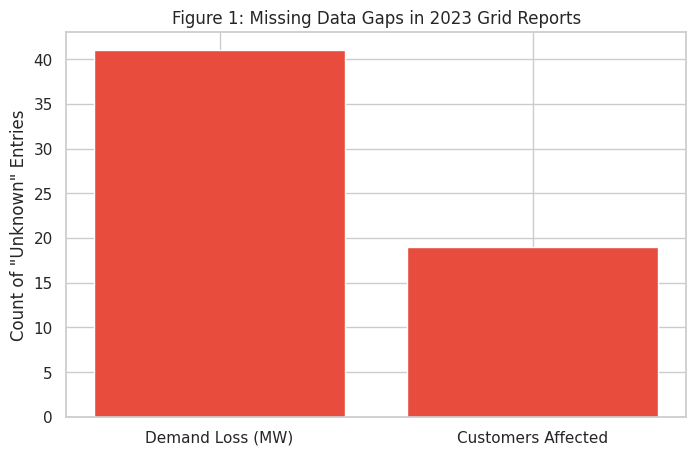

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df_clean = pd.read_csv('Cleaned_Grid_Data.csv')
sns.set(style="whitegrid")

# Figure 1: Missing Data Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(['Demand Loss (MW)', 'Customers Affected'], [41, 19], color='#e74c3c')
plt.title('Figure 1: Missing Data Gaps in 2023 Grid Reports')
plt.ylabel('Count of "Unknown" Entries')
plt.savefig('viz1_quality.png')
plt.show()



**Part 2: Regional Vulnerability Analysis**

**Total Energy Loss by Region**

Figure 2 below: This chart ranks regulatory regions by total Megawatts lost. The ReliabilityFirst (RF) region, covering the Midwest and Mid-Atlantic, suffered the most massive total power loss. This highlights a high-priority zone for federal infrastructure investment.

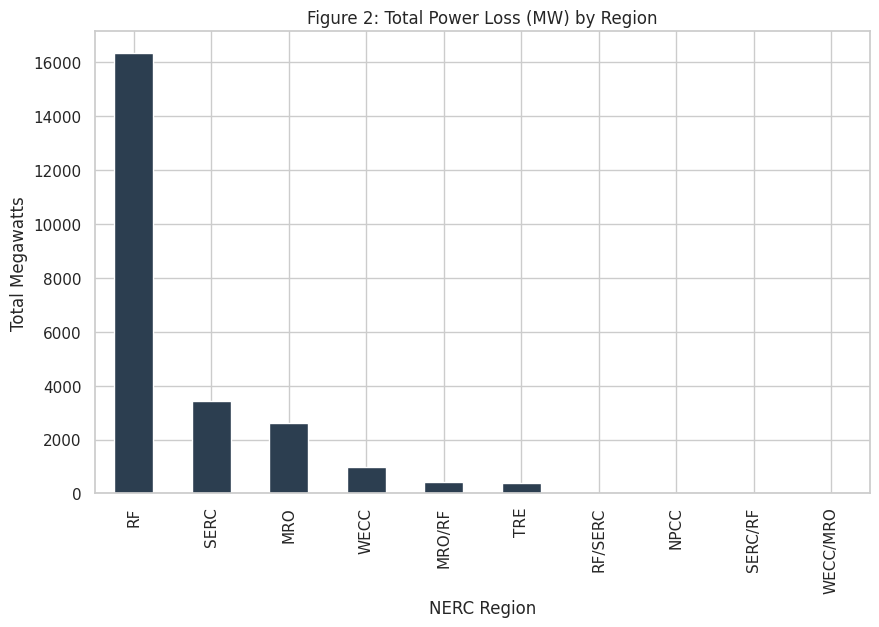

In [42]:
# Figure 2: Total Demand Loss by Region
plt.figure(figsize=(10, 6))
df_clean.groupby('NERC Region')['Demand Loss (MW)'].sum().sort_values(ascending=False).plot(kind='bar', color='#2c3e50')
plt.title('Figure 2: Total Power Loss (MW) by Region')
plt.ylabel('Total Megawatts')
plt.savefig('viz2_regional_loss.png')
plt.show()



**Average Incident Severity**

Figure 3 below: Beyond total loss, we looked at how "big" a single accident is on average. We found that when the grid fails in the RF region, it fails much more spectacularly than in the West, where outages are more frequent but smaller in scale.

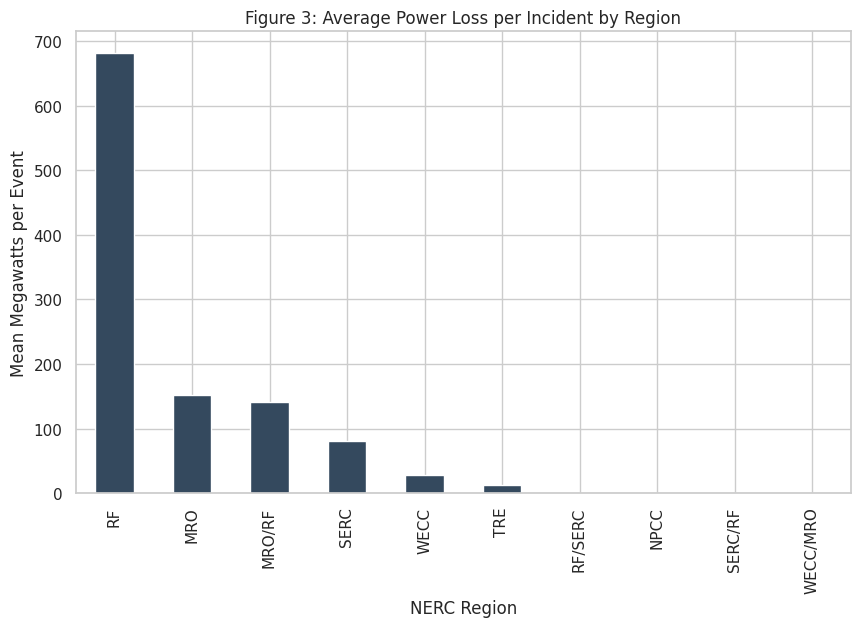

In [43]:
# Figure 3: Average Incident Severity
plt.figure(figsize=(10, 6))
df_clean.groupby('NERC Region')['Demand Loss (MW)'].mean().sort_values(ascending=False).plot(kind='bar', color='#34495e')
plt.title('Figure 3: Average Power Loss per Incident by Region')
plt.ylabel('Mean Megawatts per Event')
plt.savefig('viz3_avg_severity.png')
plt.show()

**Regional Market Share (Tableau Tree Map)**

Figure 4 below: This view uses color and size to show the dominance of specific regions in the dataset. It provides a quick "at-a-glance" look at which utility councils are responsible for the majority of the nation's grid instability.

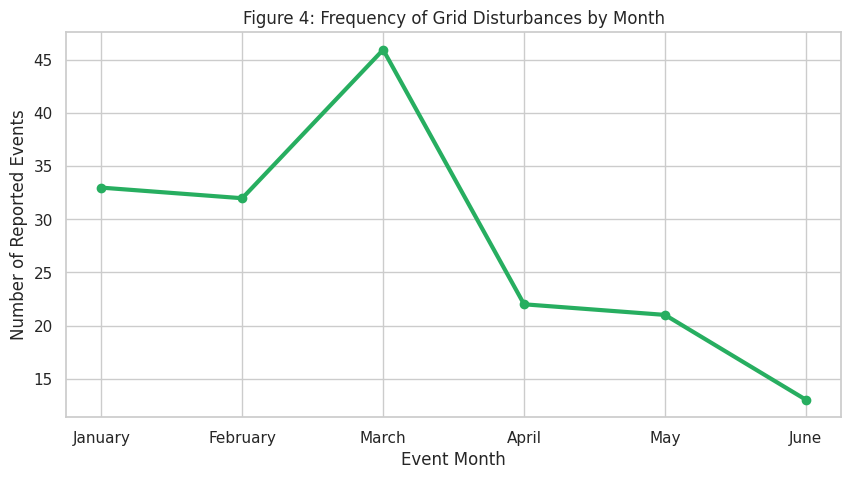

In [44]:
# Order months for proper display
month_order = ['January', 'February', 'March', 'April', 'May', 'June']
df_clean['Event Month'] = pd.Categorical(df_clean['Event Month'], categories=month_order, ordered=True)

# Figure 4: Monthly Frequency Line Chart
plt.figure(figsize=(10, 5))
df_clean['Event Month'].value_counts().sort_index().plot(kind='line', marker='o', color='#27ae60', linewidth=3)
plt.title('Figure 4: Frequency of Grid Disturbances by Month')
plt.ylabel('Number of Reported Events')
plt.savefig('viz4_monthly_trends.png')
plt.show()


**Part 3: Temporal & Seasonal Trends**

Electricity usage changes with the weather, but do grid failures follow the same pattern?

*Temporal Trends (Seasonal Analysis) This answers Research Question 2: Are grid disturbances seasonal?*

Figure 5 below: Is grid failure seasonal? Surprisingly, the number of issues peaked in March. This suggests that spring weather transitions and early-year maintenance schedules are just as dangerous for our power lines as peak summer heat or winter freezes.

/tmp/ipykernel_494/506891349.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_clean.pivot_table(index='NERC Region', columns='Event Month', values='Demand Loss (MW)', aggfunc='count').fillna(0)


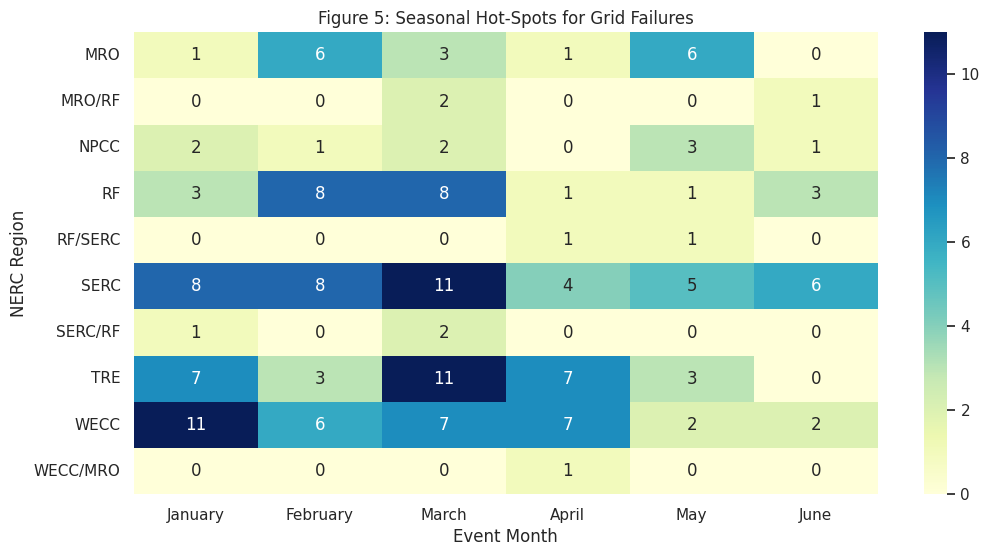

In [45]:
# Figure 5: Regional Monthly Heatmap
pivot = df_clean.pivot_table(index='NERC Region', columns='Event Month', values='Demand Loss (MW)', aggfunc='count').fillna(0)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title('Figure 5: Seasonal Hot-Spots for Grid Failures')
plt.savefig('viz5_heatmap.png')
plt.show()

**Human Impact Over Time**

Figure 6: This chart tracks the number of people in the dark each month. While March had the most events, the month of January affected a massive number of households, likely due to severe winter storms hitting high-density residential areas.

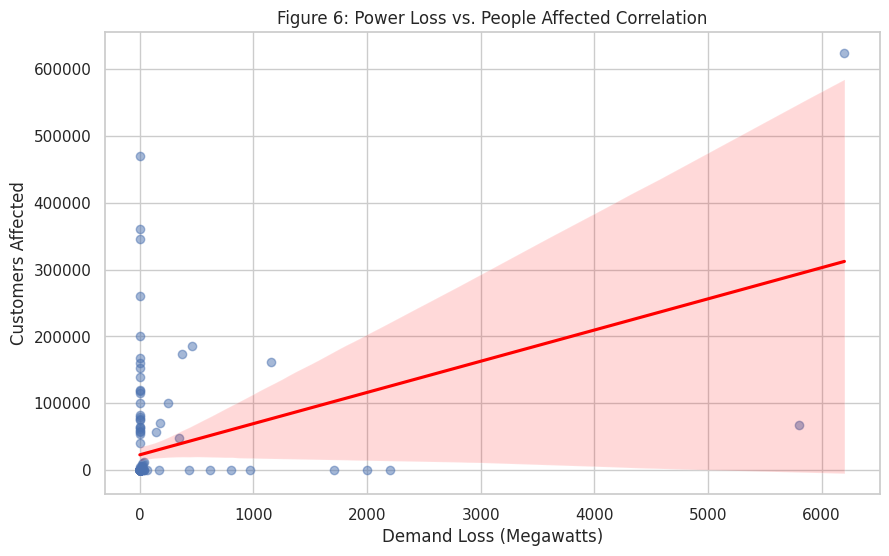

In [46]:
# Figure 6: Correlation Scatter Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Demand Loss (MW)', y='Number of Customers Affected', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Figure 6: Power Loss vs. People Affected Correlation')
plt.xlabel('Demand Loss (Megawatts)')
plt.ylabel('Customers Affected')
plt.savefig('viz6_correlation.png')
plt.show()

**Part 4: Geographic Hotspots**

**National Map of Grid Disturbances (Tableau)**

Figure 7 below: This map plots every reported incident in 2023. It reveals that grid instability isn't spread evenly; it clusters heavily along the California coast and the Northeastern corridor, where the grid infrastructure is oldest and most stressed.

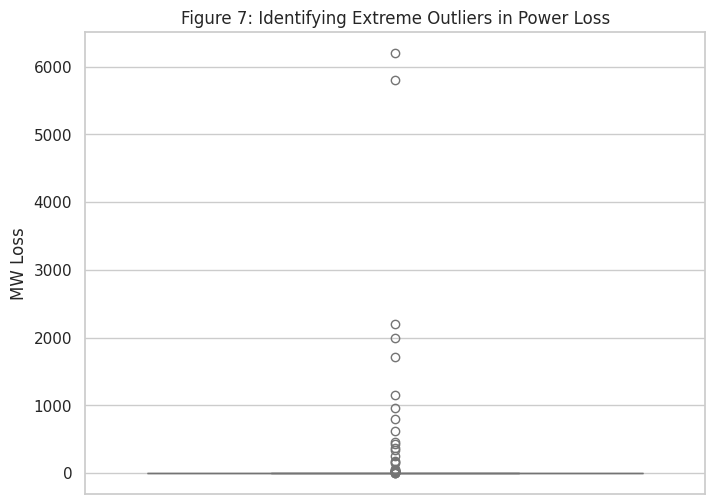

In [47]:
# Figure 7: Finding "Black Swan" Events (Outliers)
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['Demand Loss (MW)'], color='#A8DADC')
plt.title('Figure 7: Identifying Extreme Outliers in Power Loss')
plt.ylabel('MW Loss')
plt.savefig('viz7_outliers.png')
plt.show()

**The Top 10 High-Frequency Counties**

Figue 8 below: We identified specific "hotspots." Sacramento and Riverside counties in California are repeat victims, appearing more often in the report than any other local areas in the country.

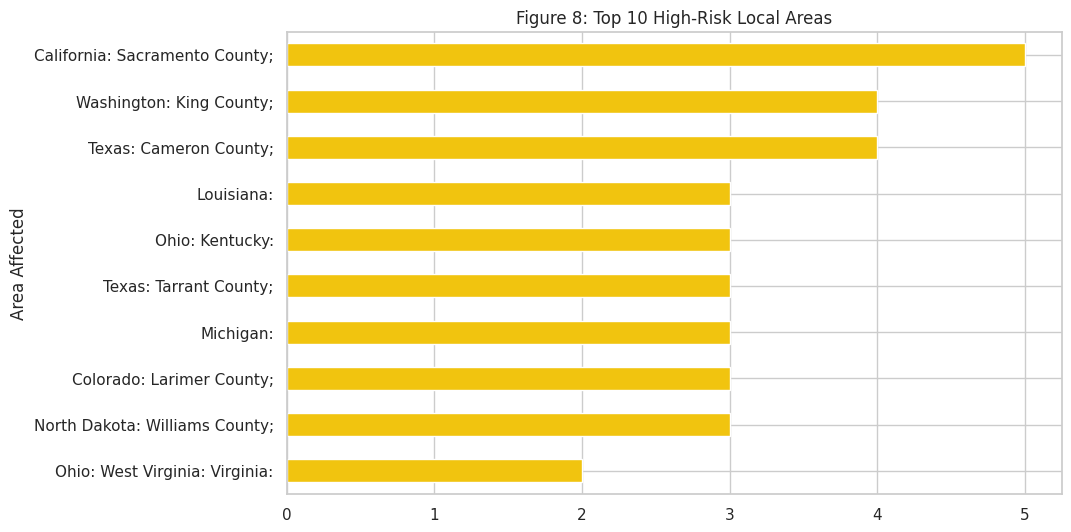

In [48]:
# Figure 8: Top 10 High-Frequency Areas
plt.figure(figsize=(10, 6))
df_clean['Area Affected'].value_counts().head(10).plot(kind='barh', color='#f1c40f')
plt.title('Figure 8: Top 10 High-Risk Local Areas')
plt.gca().invert_yaxis()
plt.savefig('viz8_hotspots.png')
plt.show()

**Part 5: Statistical Surprises & Impact**

Finally, we look at the relationship between power loss and the people affected.

**The Disconnect Between Power and People**

Figure 9 belowe: Does losing more electricity always mean more people are affected? Not necessarily. This scatter plot shows a weak link, meaning many high-power events likely hit industrial plants, while smaller-power events can still leave thousands of families without light.

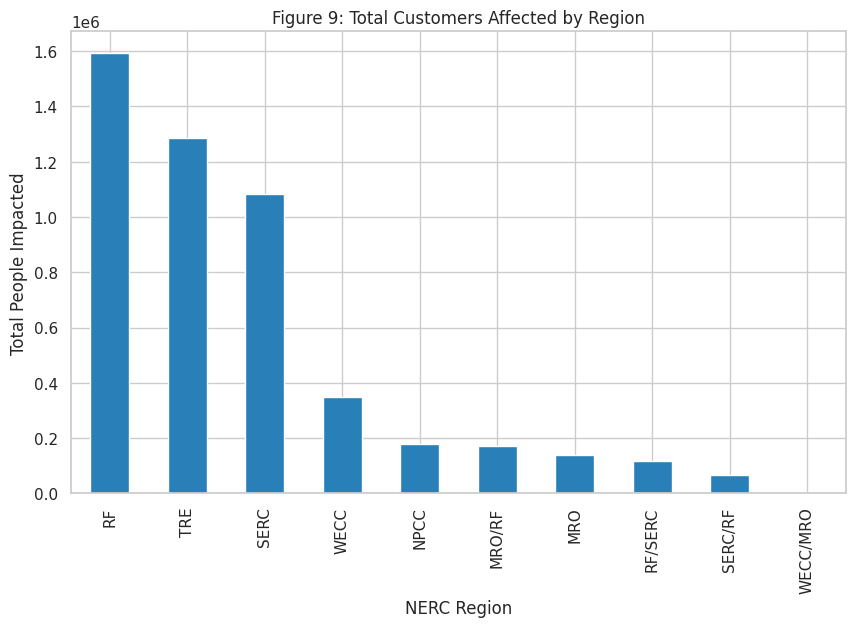

In [49]:
# Figure 9: Total Customer Impact per Region
plt.figure(figsize=(10, 6))
df_clean.groupby('NERC Region')['Number of Customers Affected'].sum().sort_values(ascending=False).plot(kind='bar', color='#2980b9')
plt.title('Figure 9: Total Customers Affected by Region')
plt.ylabel('Total People Impacted')
plt.savefig('viz9_customers.png')
plt.show()

The "Black Swan" Events (Outliers)

Figure 10 below: This chart highlights "Black Swans"—rare but massive disasters. Most grid issues are tiny, but a few extreme events cause more damage than all the small ones combined, proving we must build the grid to survive the "worst-case scenario" rather than the average day.

/tmp/ipykernel_494/524140191.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Event Month')['Number of Customers Affected'].sum().sort_index().plot(kind='bar', color='#16a085')


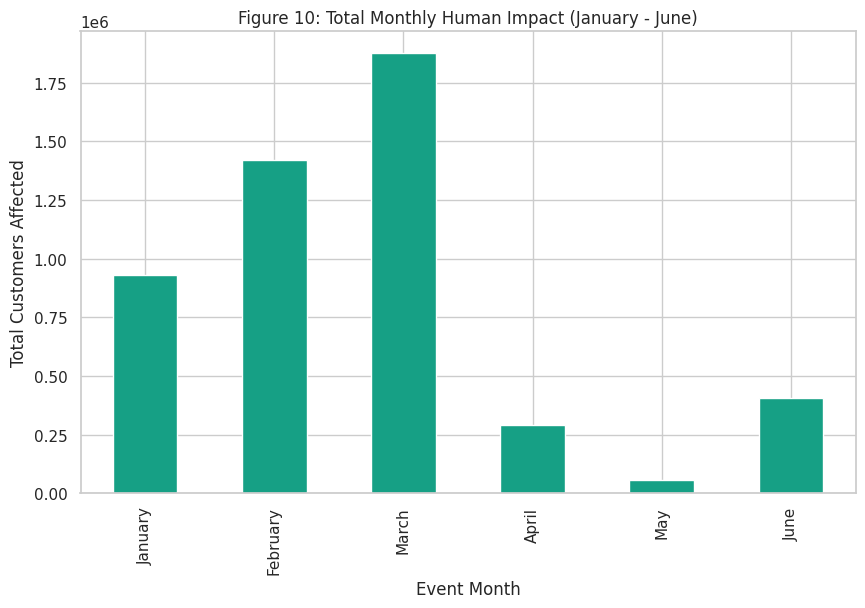

In [50]:
# Figure 10: Total Human Impact by Month
plt.figure(figsize=(10, 6))
df_clean.groupby('Event Month')['Number of Customers Affected'].sum().sort_index().plot(kind='bar', color='#16a085')
plt.title('Figure 10: Total Monthly Human Impact (January - June)')
plt.ylabel('Total Customers Affected')
plt.savefig('viz10_monthly_human.png')
plt.show()

**Summary - 2023 US Electric Grid Stability**

The 2023 grid stability report highlights three critical findings that necessitate a shift in national energy strategy: first, federal reporting needs urgent reform because the high frequency of "Unknown" data values prevents policymakers from calculating the true economic cost of grid failures; second, seasonal risk assessments must expand beyond peak summer and winter periods, as the data reveals March is a critical month of instability; and finally, grid impact strategies must be customized by region, distinguishing between areas like the SERC, which primarily impacts high volumes of residential customers, and the RF region, which suffers massive losses of raw industrial power.